# Footfall Bradford 2025 Data

In [1]:
pip install matplotlib geopandas numpy scipy folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

In [3]:
#Load footfall file
footfall = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\footfall-mix.csv")
footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2993 non-null   object 
 1   centre_name                        2993 non-null   object 
 2   purchasing_power_quantile          2993 non-null   int64  
 3   estimated_actual_footfall          2985 non-null   float64
 4   estimated_actual_footfall_rolling  2993 non-null   int64  
 5   source                             2993 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 140.4+ KB


In [4]:
#Check what data looks like
footfall.head(50)

,datestamp,centre_name,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling,source
0,2018-12-01,Bradford - City Centre,0,1044119.0,1114410,huq-bradford-city-of-culture/bradford/monthly/...
1,2018-12-01,Bradford - Penistone Hill,0,259336.0,252163,huq-bradford-city-of-culture/bradford/monthly/...
2,2018-12-01,Cliffe Castle Park - BD20 6,0,429813.0,418475,huq-bradford-city-of-culture/greenspaces/month...
3,2018-12-01,Lister Park - BD9 4,0,420360.0,524397,huq-bradford-city-of-culture/greenspaces/month...
4,2018-12-01,Wibsey Park - BD6 3,0,395650.0,381930,huq-bradford-city-of-culture/greenspaces/month...
5,2019-01-01,Bradford - City Centre,0,889518.0,1018120,huq-bradford-city-of-culture/bradford/monthly/...
6,2019-01-01,Bradford - Penistone Hill,0,542035.0,509069,huq-bradford-city-of-culture/bradford/monthly/...
7,2019-01-01,Bradford BID,0,88835.0,90080,huq-bradford-city-of-culture/bradford/daily/fo...
8,2019-01-01,Cliffe Castle Park - BD20 6,0,449579.0,432696,huq-bradford-city-of-culture/greenspaces/month...
9,2019-01-01,Lister Park - BD9 4,0,467829.0,444168,huq-bradford-city-of-culture/greenspaces/month...


In [5]:
#Check start and end dates of dataset
footfall['datestamp'].unique()

array(['2018-12-01', '2019-01-01', '2019-01-02', ..., '2025-11-08',
       '2025-11-09', '2025-11-10'], dtype=object)

In [6]:
footfall.describe()

,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling
count,2993.0,2.985000e+03,2.993000e+03
mean,0.0,1.081924e+05,1.088042e+05
std,0.0,1.278208e+05,1.273206e+05
min,0.0,8.004000e+03,1.740500e+04
25%,0.0,5.645600e+04,5.990300e+04
50%,0.0,8.005300e+04,8.260800e+04
75%,0.0,1.114750e+05,1.064750e+05
max,0.0,2.125277e+06,1.941261e+06


Look at min and max 'estimated actual footfall rolling' to get an idea of the range of values:

In [7]:
min = footfall[footfall['estimated_actual_footfall_rolling'] == footfall['estimated_actual_footfall_rolling'].min()]
min.head()

,datestamp,centre_name,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling,source
608,2020-05-17,Bradford BID,0,15430.0,17405,huq-bradford-city-of-culture/bradford/daily/fo...


In [8]:
max = footfall[footfall['estimated_actual_footfall_rolling'] == footfall['estimated_actual_footfall_rolling'].max()]
max.head()

,datestamp,centre_name,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling,source
259,2019-08-01,Bradford - City Centre,0,1696100.0,1941261,huq-bradford-city-of-culture/bradford/monthly/...


In [9]:
#Check unique area names
footfall['centre_name'].unique()

array(['Bradford - City Centre', 'Bradford - Penistone Hill',
       'Cliffe Castle Park - BD20 6', 'Lister Park - BD9 4',
       'Wibsey Park - BD6 3', 'Bradford BID', 'Bowling Park - BD4 7'],
      dtype=object)

In [10]:
#Convert datestamp to datetime
footfall['datestamp'] = pd.to_datetime(footfall['datestamp'])

Notes:
* Don't know if should be looking at normal or rolling footfall? 
* Normal footfall has 164 data poinst missing ?

In [11]:
#Check missing data in 'estimated actual footfall'
footfall['estimated_actual_footfall'].isna().value_counts()
#have _ days with missing footfall information

estimated_actual_footfall
False    2985
True        8
Name: count, dtype: int64

In [12]:
#Check missing data in 'estimated actual footfall rolling'
footfall['estimated_actual_footfall_rolling'].isna().value_counts()
#have _ missing data points

estimated_actual_footfall_rolling
False    2993
Name: count, dtype: int64

## Investigating 'Estimated Actual Footfall Rolling'

## Exploring Footfall Time Series

In [13]:
# Plot exploratory line graph of footfall throughout time
# have hover option to check exact daily footfall count

import plotly.express as px

fig_BradFF = px.line(footfall, 
                     x ='datestamp', 
                     y='estimated_actual_footfall_rolling', 
                     title='Footfall in Bradford',
                     labels= { 'datestamp': 'Date',
                               'estimated_actual_footfall': 'Visitors'})
fig_BradFF.update_traces(
    hovertemplate='📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:,}'
)
fig_BradFF.update_layout(
    xaxis_title='Date',
    yaxis_title='Footfall',
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
fig_BradFF.show()


In [14]:
#Plot interactive line graph of footfall throughout time,
#with button to select area of interest
# with hover option to check exact daily footfall count

import plotly.graph_objects as go

#Isolate regions and 
regions = footfall['centre_name'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []
trace_count = 0

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')
    
    #Add traces for this variable
    fig_BradFF.add_scatter(
            x= df_region['datestamp'],
            y= df_region['estimated_actual_footfall_rolling'],
            mode='lines',
            name= region,
            line= dict(color='blue', width=2, dash='solid'),
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )
    
    trace_count += 1

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * trace_count
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    title= f'Footfall Trend - {regions[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Footfall',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)

fig_BradFF.show()

Smooth trend line

In [15]:
#Smooth Spline Curve
#Plot interactive line graph of footfall in Met Office Bradford wider region throughout time
import plotly.express as px
from scipy.interpolate import make_interp_spline
import plotly.graph_objects as go

#Isolate regions
regions = footfall['centre_name'].unique()

#Create initial figure
fig_BradFF = go.Figure()
buttons = []

#Loop through each region
for i, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')

    #Data prep
    x = df_region['datestamp']
    y = df_region['estimated_actual_footfall_rolling']

    #Create smoothed line with interpolation
    x_numeric = np.arange(len(x))
    X_Y_Spline = make_interp_spline(x_numeric, y)
    X_ = np.linspace(x_numeric.min(), x_numeric.max(), 500)
    Y_ = X_Y_Spline(X_)

    #Convert the dates back to show timeframe
    x_seconds = np.array([dt.timestamp() for dt in x])
    X_dates_seconds = np.interp(X_, x_numeric, x_seconds)
    X_dates = pd.to_datetime(X_dates_seconds, unit='s')
    
    #Add traces for this variable
    fig_BradFF.add_trace(
        go.Scatter(
            x= X_dates,
            y= Y_,
            mode='lines',
            line= dict(color='blue', width=2, dash='solid'),
            name= region,
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}')
        )

#Add buttons for dropdown menu
for i, region in enumerate(regions):
    visible_array = [False] * len(regions)
    visible_array[i] = True
    buttons.append(dict(
        label=region,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Footfall Trend - {region}'}]
    ))

#Add dropdown and choose layout
fig_BradFF.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top'
    )],
    title= f'Footfall Trend - {regions[0]}',
    xaxis_title='Date',
    yaxis_title='Footfall',
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
    
fig_BradFF.show()

## Comparing footfall seasonal trends in 2024 VS 2025

In [16]:
# Plot seasonal footfall line graph,
# with months on the x axis
# allowing to compare footfall between 2024 and 2025
# with a button to select the area of interest

import plotly.express as px
import plotly.graph_objects as go

#Isolate the different regions
regions = footfall['centre_name'].unique()

#Create initial empty figure
fig_Brad24vs25 = go.Figure()
buttons = []

#Loop through each region
for r, region in enumerate(regions):
    df_region = footfall[footfall['centre_name'] == region].sort_values('datestamp')

    #Add 2024 and 2025 lines
    for year, color in zip([2024, 2025], ['blue', 'red']):
        df_year = df_region[df_region['datestamp'].dt.year == year].copy()
        if df_year.empty:
            continue

        x_doy = df_year['datestamp'].dt.dayofyear
        y = df_year['estimated_actual_footfall_rolling']

        #Add lines
        fig_Brad24vs25.add_scatter(
        x= x_doy,
        y= y,
        mode='lines',
        line= dict(color= color, width=2),
        name= f'{year}',
        visible=(r==0),
        customdata= df_year['datestamp'],
        hovertemplate= '📅 %{customdata|%Y-%m-%d}<br> 👣Footfall: %{y:.1f}'
    )

#Add 1 button per region
visibility = [False] * (2 * len(regions))
visibility[i*2] = True #2024 line
visibility[i*2+1] = True #2025 line

buttons.append(dict(
    label=region,
    method='update',
    args=[{'visible': visibility},
        {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
))

#Add buttons for dropdown
for i, region in enumerate(regions):
        visible_array = [False] * (2* len(regions))
        visible_array[2*i] = True #2024 line
        visible_array[2*i +1] = True #2025 line
        buttons.append(dict(
            label= region,
            method='update',
            args=[{'visible': visible_array},
                 {'title': f'Footfall Comparison (2024 vs 2025) - {region}'}]
        ))

#Adapt layout with monthly ticks
month_starts = pd.date_range('2024-01-01', '2024-12-31', freq='MS')
month_labels = month_starts.strftime('%b')


#Add dropdown and choose layout
fig_Brad24vs25.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction= 'down',
        x= 0.01,
        y=1.3,
        xanchor= 'left',
        yanchor= 'top',
        showactive= True
    )],
    hovermode= 'x unified',
    title= f'Footfall Comparison (2024 vs 2025) - {regions[0]}',
    xaxis=dict(
        title= 'Month',
        tickvals=[d.timetuple().tm_yday for d in month_starts],
        ticktext= month_labels,
        range=[1, 366],
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
         title='Footfall (Estimated Actual Rolling)',
         showgrid= True,
         gridcolor='lightgrey',
         zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
    
fig_Brad24vs25.show()


In [17]:
#Save plot as HTML
fig_Brad24vs25.write_html('footfall_graph.html')

## Exploring Daily + Seasonal Footfall Heatmaps

Make daily heatmap with buttons to select the year and the area of interest.

WARNING: this heatmap code worked for the Bradford Metropolitan data but doesn't with the current version of the footfall data, issue will need to be resolved as currently it does not plot all the days, just the first day of the month!

In [18]:
footfall['Year'] = footfall['datestamp'].dt.year

In [19]:
#Daily heatmap for each year and area of interest

#Set up yearly and region filtering
years = sorted(footfall['Year'].unique())
regions = sorted(footfall['centre_name'].unique())

#Start with first year and first region to initialize figure
first_year = years[0]
first_region = regions[0]

#--------------------------------------------------------------------------------------------------------------------------------


#Create fucntion to create pivot table with all dates for a year
#get full list of dates no matter if data is missing on some days
def create_pivot(year, region):
    all_dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31', freq='D')
    df_full = pd.DataFrame({'datestamp': all_dates})
    df_full['day_of_week'] = df_full['datestamp'].dt.weekday
    df_full['week_index']= df_full['datestamp'].dt.isocalendar().week

    #Extract footfall rows
    data = footfall[(footfall['Year'] == year) & (footfall['centre_name'] == region)].copy()
    data['datestamp'] = pd.to_datetime(data['datestamp'])

    #Merge the full calendar with footfall data
    data_merged = df_full.merge(data, how='left', on='datestamp')

    #Pivot for heatmap
    pivot = data_merged.pivot_table(index='day_of_week', 
                                    columns='week_index', 
                                    values='estimated_actual_footfall_rolling',
                                    aggfunc= 'first')
    pivot = pivot.reindex(index=range(7), columns=range(1, 54))

    #Pivot for hover data
    data_merged['date_str'] = data_merged['datestamp'].dt.strftime('%Y-%m-%d')
    customdata = data_merged.pivot_table(index='day_of_week', 
                                         columns='week_index', 
                                         values='date_str',
                                         aggfunc='first')
    customdata = customdata.reindex(index=range(7), columns=range(1, 54)).values

    return pivot, customdata



In [20]:
#Initial data
pivot_init, customdata_init = create_pivot(first_year, first_region)

#Plot Interactive Daily Heatmap
fig = px.imshow(
    pivot_init.values,
    labels= dict(x='Week of Year', y='Day of Week', color='Footfall'),
    x=pivot_init.columns,
    y=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    color_continuous_scale='viridis_r',
    aspect='auto',
)

#Add hover with daily info
fig.update_traces(
    hovertemplate= '📅Date:%{customdata}<br> 👣Footfall: %{z:,}',
    customdata= customdata_init
)

#Create dropdown button for years
year_buttons= []
for year in years:
    pivot_y, customdata_y = create_pivot(year, first_region)
    year_buttons.append(dict(
        label=str(year), #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_y.values], 'customdata': [customdata_y]},
              {'title': f'Daily Footfall Heatmap - {year} - {first_region}'}]
    ))

#Create dropdown button for region
region_buttons= []
for region in regions:
    pivot_r, customdata_r = create_pivot(first_year, region)
    region_buttons.append(dict(
        label= region, #text shown in drop down
        method='update', #update data instead of redrawing
        #z is new heatmap values, customdata is hover data
        args=[{'z': [pivot_r.values], 'customdata': [customdata_r]},
              {'title': f'Daily Footfall Heatmap - {first_year} - {region}'}]
    ))


#Add both dropdown menus
fig.update_layout(
    title= f'Daily Footfall Heatmap - {first_year} - {first_region}',
    updatemenus=[
        dict(buttons= year_buttons, direction='down', x=1, y=1.2, showactive=True, pad={'r':10}, name='Year'),
        dict(buttons= region_buttons, direction='down', x=0.9, y=1.2, showactive=True, pad={'r':10}, name='Region')
    ]
)

**Notes:**
* Based on line plots, there is a significant increase (almost double overnight) in footfall in the Bradford overall region on the 25th of january 2025 -> need to investigate cause, maybe start of Bradford25 events
* The opening night of Bradford 2025 was the 10th of january so cant be that, 25th of jan is burns night tho
* Highest footfall peak occured on the 5th of October 2025 -> investigate what event happened on that day
* Day with the lowest footfall was the 6th of January 2019

In [21]:
#Check of many data poinst for certain regions
AreaCheck = footfall[footfall['centre_name'] == 'Bradford - BID']
AreaCheck.count()

datestamp                            0
centre_name                          0
purchasing_power_quantile            0
estimated_actual_footfall            0
estimated_actual_footfall_rolling    0
source                               0
Year                                 0
dtype: int64

## Exploring geographical patterns of footfall

In [22]:
#Load file with different geographical areas of Bradford
areas = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\areas.geojson")

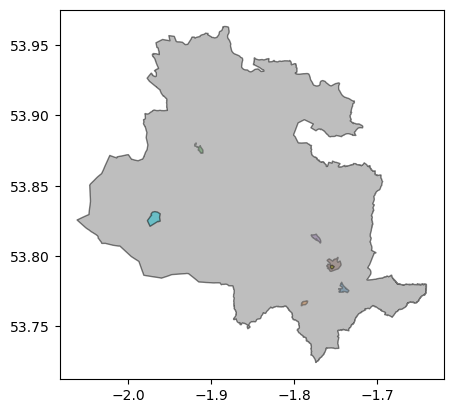

In [23]:
#Plot
areas.plot(cmap='tab10', edgecolor='black', alpha= 0.5, legend=True)
plt.show()

In [24]:
#Have 8 areas
areas.head(10)

,centre_name,geometry
0,Bowling Park - BD4 7,"POLYGON ((-1.74342 53.78017, -1.74338 53.78022..."
1,Wibsey Park - BD6 3,"POLYGON ((-1.79115 53.76468, -1.79115 53.76482..."
2,Cliffe Castle Park - BD20 6,"POLYGON ((-1.91566 53.87713, -1.91694 53.87755..."
3,Lister Park - BD9 4,"POLYGON ((-1.77676 53.81297, -1.77673 53.81299..."
4,Bradford BID,"POLYGON ((-1.75387 53.78933, -1.75416 53.78928..."
5,Met Office - Bradford,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284..."
6,Bradford - City Centre,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."
7,Bradford - Penistone Hill,"POLYGON ((-1.97655 53.82517, -1.97316 53.8279,..."


In [25]:
#Extract Met Office wider region of Bradford
MetOBrad = areas[areas['centre_name'] == 'Met Office - Bradford']
MetOBrad.head()

,centre_name,geometry
5,Met Office - Bradford,"POLYGON ((-1.88042 53.96298, -1.87951 53.96284..."


In [26]:
#Print CRS
print(areas.crs)

EPSG:4326


## Interactive Map of Footfall

In [27]:
#Set up

#Choose center of map as center of the Bradford Met Office polygon (largest area)
# by taking mean lat and long
# need to reproject to find centroid
MetOBrad_projected = MetOBrad .to_crs(epsg=27700)
centroids_projected = MetOBrad_projected.centroid
centroids = gpd.GeoSeries(centroids_projected, crs=27700).to_crs(4326)

center = [centroids.y.mean(), centroids.x.mean()]

In [28]:
#Merge the polygons and the footfall data
DFmap = footfall.merge(areas[['centre_name', 'geometry']], on='centre_name')
GDFmap = gpd.GeoDataFrame(DFmap, geometry='geometry')
#Check CRS
print(GDFmap.crs)

EPSG:4326


In [29]:
GDFmap.head()

,datestamp,centre_name,purchasing_power_quantile,estimated_actual_footfall,estimated_actual_footfall_rolling,source,Year,geometry
0,2018-12-01,Bradford - City Centre,0,1044119.0,1114410,huq-bradford-city-of-culture/bradford/monthly/...,2018,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."
1,2019-01-01,Bradford - City Centre,0,889518.0,1018120,huq-bradford-city-of-culture/bradford/monthly/...,2019,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."
2,2019-02-01,Bradford - City Centre,0,1010175.0,897949,huq-bradford-city-of-culture/bradford/monthly/...,2019,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."
3,2019-03-01,Bradford - City Centre,0,1481604.0,1224704,huq-bradford-city-of-culture/bradford/monthly/...,2019,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."
4,2019-04-01,Bradford - City Centre,0,1494493.0,1471109,huq-bradford-city-of-culture/bradford/monthly/...,2019,"POLYGON ((-1.75155 53.79246, -1.75298 53.79139..."


In [30]:
#Create footfall-based dynamic coloring of map
#choose colormap
cmap = plt.cm.viridis_r
#Normalize footfall values to 0-1 range by taking min and max as range
norm = matplotlib.colors.Normalize(
    vmin= GDFmap['estimated_actual_footfall_rolling'].min(),
    vmax= GDFmap['estimated_actual_footfall_rolling'].max()
)

#Create function to convert footfall to hex color
def get_color(footfall_value):
    return matplotlib.colors.to_hex(cmap(footfall_value))

In [31]:
#Convert the GeoDataFrame into GeoJson
# so it can used by TimestampedGeoJson to make time sliced map
# create features list per time step

#Create GeoJSON features
# create empty lists to store GeoJson dictionaries
features = []

#Sort the data by date and then
#Sort the different area polygons by descending size each day
# so that smaller polygons are added last (easier to hover when overlapping)
GDFmap['area'] = GDFmap.geometry.area
GDFmap = GDFmap.sort_values(['datestamp', 'area'], ascending=[True, False])

#Loop through each row to create dictionary
for r, row in GDFmap.iterrows():
    color = matplotlib.colors.to_hex(cmap(norm(row['estimated_actual_footfall_rolling'])))
    #Use last available geometry for that centre
    feature = {
        'type': 'Feature', #every feature represents one polygon on map
        'geometry': row['geometry'].__geo_interface__, # convert geometry into GeoJson compatible format
        'properties': { #add addiotional info
            'time': row['datestamp'].strftime('%Y-%m-%d'), #time steps
            'popup': f"<b>Area:</b> {row['centre_name']}<br>"
                     f"<b>Date: </b> {row['datestamp'].strftime('%Y-%m-%d')} <br>"
                     f"<b>Footfall: </b> {row['estimated_actual_footfall_rolling']:,.0f}",
            'style': {
                'fillColor':color, #dynamic inside color
                'color': 'black', #border color
                'weight': 1, #border thickness
                'fillOpacity': 0.4 #transparency
            }
        }
    }
    features.append(feature)

#Create GeoJson, standard format expected by folium
geojson = {
    'type': 'FeatureCollection',
    'features': features
}

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_36100\3677862864.py:12: UserWarning:

Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [32]:
#Create Interactive Map with Folium
import folium
from folium.plugins import TimestampedGeoJson
import branca.colormap as cm

#Create map
# location deciddes where center of map is
# zoom_start sets how zoomed in the map is
# tiles sets the background map style
IntMap = folium.Map(location = center, zoom_start = 11, tiles= 'OpenStreetMap')

TimestampedGeoJson(
    data= geojson,
    transition_time= 200, #animation speed when moving timestamp
    period= 'P1D', #each time step represents one day
    duration = 'P1D', #hide each feature after 1 day, so no stacking
    auto_play= False,
    add_last_point= False,
    loop= False,
    loop_button= False,
    date_options= 'YYYY-MM-DD',
    time_slider_drag_update= True
).add_to(IntMap)

#Create a legend colorbar matching polygons coloring
vmin = GDFmap['estimated_actual_footfall_rolling'].min()
vmax= GDFmap['estimated_actual_footfall_rolling'].max()
colormap = cm.LinearColormap(
    colors=[matplotlib.colors.to_hex(cmap(i/255)) for i in range (256)],
    vmin= vmin,
    vmax= vmax,
    caption= 'Estimated Actual Footfall (Rolling)',
    tick_labels= [15000, 300000, 500000, 800000, 1000000, 1500000, 1800000]
)

#Add colormap/colorbar to the map
colormap.add_to(IntMap)

IntMap.save('footfall_map.html')

In [33]:
#Create Interactive Map with Folium
import folium
from folium.plugins import TimestampedGeoJson
import branca.colormap as cm

#Create map
# location deciddes where center of map is
# zoom_start sets how zoomed in the map is
# tiles sets the background map style
IntMap = folium.Map(location = center, zoom_start = 11, tiles= 'OpenStreetMap')

TimestampedGeoJson(
    data= geojson,
    transition_time= 200, #animation speed when moving timestamp
    period= 'P1D', #each time step represents one day
    duration = 'P1D', #hide each feature after 1 day, so no stacking
    auto_play= False,
    add_last_point= False,
    loop= False,
    loop_button= False,
    date_options= 'YYYY-MM-DD',
    time_slider_drag_update= True
).add_to(IntMap)

#Create a legend colorbar matching polygons coloring
vmin = GDFmap['estimated_actual_footfall_rolling'].min()
vmax= GDFmap['estimated_actual_footfall_rolling'].max()
ticks= np.linspace(vmin, vmax, 6).astype(int)
colormap = cm.LinearColormap(
    colors=[matplotlib.colors.to_hex(cmap(i/255)) for i in range (256)],
    vmin= vmin,
    vmax= vmax,
    caption= 'Estimated Actual Footfall (Rolling)',
)

#Add colormap/colorbar to the map
colormap.add_to(IntMap)

IntMap.save('footfall_map.html')

# Mastercard data Bradford 2025

### Data dictionary

Metric | Description
-------|--------------
Avg ticket | Average ticket index measuring average spend per transaction in the area
Avg spend amt | Average spend amt index measuring average spend per card number in the area
Avg transaction amt | Transaction amount index measuring total spend in the area
Avg transactions | Transaction count index measuring total number of transactions in the area
Avg accounts | Account count index measuring totla number of distinct card numbers in the area
Avg frequency | Average frequency index measuring average number of transactions per card number in the area



In [34]:
mastercard = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\mastercard.csv")
mastercard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1369
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datestamp  1370 non-null   object 
 1   variable   1370 non-null   object 
 2   value      1365 non-null   float64
dtypes: float64(1), object(2)
memory usage: 32.2+ KB


In [35]:
mastercard.head(50)

,datestamp,variable,value
0,2024-12-01,average_account_count,215.487
1,2024-12-01,average_spend_amount,39.976
2,2024-12-01,average_ticket,37.567
3,2024-12-01,transaction_amount,141.569
4,2024-12-01,transaction_count,223.071
5,2024-12-02,average_account_count,241.902
6,2024-12-02,average_spend_amount,48.660
7,2024-12-02,average_ticket,46.833
8,2024-12-02,transaction_amount,157.405
9,2024-12-02,transaction_count,244.416


In [36]:
mastercard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1369
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datestamp  1370 non-null   object 
 1   variable   1370 non-null   object 
 2   value      1365 non-null   float64
dtypes: float64(1), object(2)
memory usage: 32.2+ KB


In [37]:
mastercard['variable'].unique()

array(['average_account_count', 'average_spend_amount', 'average_ticket',
       'transaction_amount', 'transaction_count'], dtype=object)

In [38]:
#Convert datestamp to datetime
mastercard['datestamp'] = pd.to_datetime(mastercard['datestamp'])

In [39]:
mastercard['datestamp'].unique()

<DatetimeArray>
['2024-12-01 00:00:00', '2024-12-02 00:00:00', '2024-12-03 00:00:00',
 '2024-12-04 00:00:00', '2024-12-05 00:00:00', '2024-12-06 00:00:00',
 '2024-12-07 00:00:00', '2024-12-08 00:00:00', '2024-12-09 00:00:00',
 '2024-12-10 00:00:00',
 ...
 '2025-08-22 00:00:00', '2025-08-23 00:00:00', '2025-08-24 00:00:00',
 '2025-08-25 00:00:00', '2025-08-26 00:00:00', '2025-08-27 00:00:00',
 '2025-08-28 00:00:00', '2025-08-29 00:00:00', '2025-08-30 00:00:00',
 '2025-08-31 00:00:00']
Length: 274, dtype: datetime64[ns]

## Plot time series with button for the different variables that can be observed
Mastercard data is not granular so no need to map it out -> only at Met Office regional scale

In [40]:
#Check for NaNs
mastercard['value'].isna().sum()

5

In [41]:
#Remove NaNs
mastercard = mastercard.dropna(subset=['value'])
mastercard['value'].isna().sum()

0

In [ ]:
#Plot interactive line graph of mastercard in Met Office Bradford wider region throughout time
#with button to select variable of interest
# with hover option to check exact daily card spending

import plotly.graph_objects as go

#Isolate variables
variables = mastercard['variable'].unique()

#Create initial figure
fig_BradMC = go.Figure()
buttons = []
trace_count = 0

#Loop through each variable
for v, var in enumerate(variables):
    df_var = mastercard[mastercard['variable'] == var].sort_values('datestamp')
    
    #Add traces for this variable
    fig_BradMC.add_scatter(
            x= df_var['datestamp'],
            y= df_var['value'],
            mode='lines',
            name= var,
            line= dict(color='blue', width=2, dash='solid'),
            visible= (i==0), #only first is visible initially
            hovertemplate= '📅 %{x|%Y-%m-%d}<br> 💳Value: %{y:.1f}'
    )
    
    trace_count += 1

#Add buttons for dropdown menu
for v, variable in enumerate(variables):
    visible_array = [False] * trace_count
    visible_array[v] = True
    buttons.append(dict(
        label=variable,
        method='update',
        args=[{'visible': visible_array},
            {'title': f'Mastercard Trend - {variable}'}]
    ))

#Add dropdown and choose layout
fig_BradMC.update_layout(
    title= f'Mastercard Trend - {variables[0]}',
    xaxis = dict(
        title= 'Date',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
        title='Mastecard',
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x= 0.1,
        y=1.2,
        xanchor= 'left',
        yanchor= 'top',
        direction='down',
        showactive= True
    )],
)

fig_BradMC.show()

In [43]:
# Plot seasonal mastercard spending line graph,
# with months on the x axis
# allowing to compare mastercard spending between 2024 and 2025
# with a button to select the variable of interest

import plotly.express as px
import plotly.graph_objects as go

#Isolate the different variables
variables = mastercard['variable'].unique()

#Create initial empty figure
fig_Brad24vs25 = go.Figure()
buttons = []

#Loop through each variable
for v, variable in enumerate(variables):
    df_variable = mastercard[mastercard['variable'] == variable].sort_values('datestamp')

    #Add 2024 and 2025 lines
    for year, color in zip([2024, 2025], ['blue', 'red']):
        df_year = df_variable[df_variable['datestamp'].dt.year == year].copy()
        if df_year.empty:
            continue

        x_doy = df_year['datestamp'].dt.dayofyear
        y = df_year['value']

        #Add lines
        fig_Brad24vs25.add_scatter(
        x= x_doy,
        y= y,
        mode='lines',
        line= dict(color= color, width=2),
        name= f'{year}',
        visible=(r==0),
        customdata= df_year['datestamp'],
        hovertemplate= '📅 %{customdata|%Y-%m-%d}<br> 💳Value: %{y:.1f}'
    )

#Add 1 button per region
visibility = [False] * (2 * len(regions))
visibility[v*2] = True #2024 line
visibility[v*2+1] = True #2025 line

buttons.append(dict(
    label=variable,
    method='update',
    args=[{'visible': visibility},
        {'title': f'Mastercard Spending Comparison (2024 vs 2025) - {variable}'}]
))

#Add buttons for dropdown
for v, variable in enumerate(variables):
        visible_array = [False] * (2* len(regions))
        visible_array[2*v] = True #2024 line
        visible_array[2*v +1] = True #2025 line
        buttons.append(dict(
            label= variable,
            method='update',
            args=[{'visible': visible_array},
                 {'title': f'Mastercard Spending Comparison (2024 vs 2025) - {variable}'}]
        ))

#Adapt layout with monthly ticks
month_starts = pd.date_range('2024-01-01', '2024-12-31', freq='MS')
month_labels = month_starts.strftime('%b')


#Add dropdown and choose layout
fig_Brad24vs25.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction= 'down',
        x= 0.01,
        y=1.3,
        xanchor= 'left',
        yanchor= 'top',
        showactive= True
    )],
    hovermode= 'x unified',
    title= f'Mastercard Comparison (2024 vs 2025) - {variables[0]}',
    xaxis=dict(
        title= 'Month',
        tickvals=[d.timetuple().tm_yday for d in month_starts],
        ticktext= month_labels,
        range=[1, 366],
        showgrid= True,
        gridcolor='lightgrey',
        zeroline= False
    ),
    yaxis= dict(
         title='Value',
         showgrid= True,
         gridcolor='lightgrey',
         zeroline= False
    ),
    template= 'ggplot2',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
    
fig_Brad24vs25.show()